In [1]:
import os, json, joblib, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
os.makedirs('artifacts', exist_ok=True)

Device: cuda


In [3]:
CFG = dict(
    # Data
    window_size   = 60,
    horizon      = 5,
    train_frac    = 0.70,
    val_frac      = 0.15,

    # Feature engineering
    roll_window   = 10,
    lag_steps     = [1, 3, 5],

    # Shared training defaults
    batch_size      = 128,
    max_epochs      = 100,
    label_smoothing = 0.0,

    # Class weighting
    minority_boost_classes = ['CALL_DROP', 'CAPACITY_EXHAUSTED'],
    lr                    = 2e-4,   # plus rapide à converger
    hidden_size           = 128,  # ~230k paramètres — bon équilibre
    num_layers            = 2,
    dropout               = 0.4,  # légèrement plus de régularisation
    patience              = 12,
    transition_oversample = 3,  # 13.2% × 3 = ~30% dans les batchs — plus raisonnable
    minority_boost        = 1.5,    # boost modéré pour CALL_DROP et CAPACITY_EXHAUSTED
    focal_gamma           = 1.0,    # gamma 1.5 trop agressif avec label_smoothing=0
    clip_grad             = 0.5,
    weight_decay          = 3e-3,

)


In [4]:
LOCAL_PATH = './data/network_qoe_latest.csv'
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PATH = '/content/drive/MyDrive/network_qoe_latest.csv'
except Exception:
    PATH = LOCAL_PATH

df_raw = pd.read_csv(PATH)
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], unit='s')
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Mounted at /content/drive
Shape: (152071, 33)


,run_id,timestamp,datetime,segment,switch_id,port_no,mos_voice,e2e_delay_ms,plr,jitter_ms,...,tx_bytes,rx_packets,tx_packets,rx_dropped,tx_dropped,dataplane_latency_ms,ctrl_plane_rtt_ms,flow_count,mos_source,label
0,run_20260409_121154,2026-04-09 11:14:46.804995775,12:14:46,INTERNET,1,4,4.4,0.0,0.0,0.0,...,0,0,0,0,0,NaN,0.0,0,ctrl_plane_fallback,NORMAL
1,run_20260409_121154,2026-04-09 11:14:46.804995775,12:14:46,OUTDOOR_RAN,1,1,4.4,0.0,0.0,0.0,...,0,0,0,0,0,NaN,0.0,0,ctrl_plane_fallback,NORMAL
2,run_20260409_121154,2026-04-09 11:14:46.804995775,12:14:46,INDOOR_RAN,1,2,4.4,0.0,0.0,0.0,...,0,0,0,0,0,NaN,0.0,0,ctrl_plane_fallback,NORMAL


=== QoE Label Distribution) ===
                    count      %
label                           
NORMAL              48735  32.05
HIGH_LATENCY        26183  17.22
LOW_THROUGHPUT      25825  16.98
POOR_VOICE_QUALITY  23455  15.42
CALL_DROP           15307  10.07
CAPACITY_EXHAUSTED  12566   8.26

Imbalance ratio: 3.9x


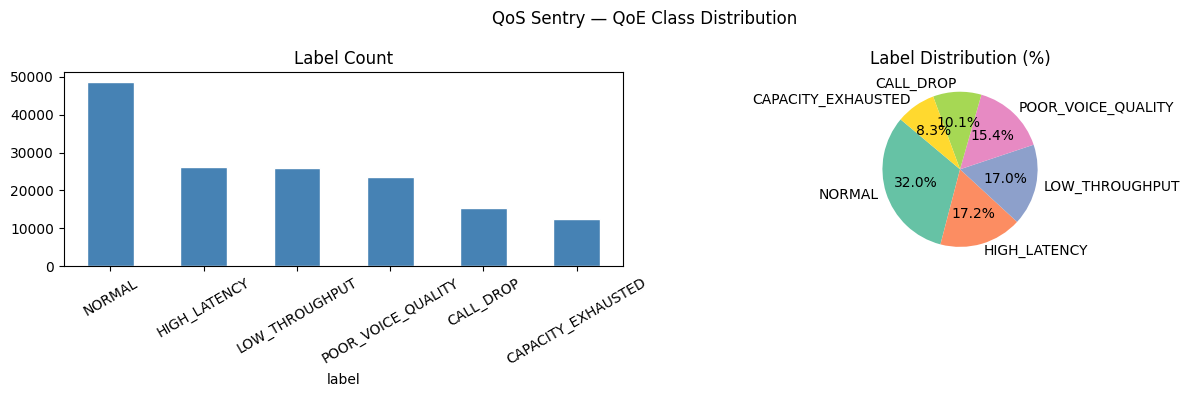

In [5]:
# ── Label distribution ────────────────────────────────────────────────────────
label_counts = df_raw['label'].value_counts()
label_pct    = label_counts / len(df_raw) * 100
print('=== QoE Label Distribution) ===')
print(pd.DataFrame({'count': label_counts, '%': label_pct.round(2)}).to_string())
print(f'\nImbalance ratio: {label_counts.max()/label_counts.min():.1f}x')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
label_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Label Count'); axes[0].tick_params(axis='x', rotation=30)
axes[1].pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',
            startangle=140, colors=plt.cm.Set2.colors)
axes[1].set_title('Label Distribution (%)')
plt.suptitle('QoS Sentry — QoE Class Distribution', fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
DROP_COLS = [
    'run_id', 'datetime', 'mos_source', 'switch_id',
    'rebuffering_count', 'total_stall_seconds', 'rx_dropped', 'tx_dropped',
]

SLA_FEATURES = [
    'e2e_delay_ms', 'jitter_ms', 'plr', 'throughput_mbps',
    'mos_voice', 'ctrl_plane_rtt_ms', 'availability',
]
LAG_COLS  = ['e2e_delay_ms', 'throughput_mbps', 'mos_voice', 'plr', 'jitter_ms', 'ctrl_plane_rtt_ms']
DIFF_COLS = ['e2e_delay_ms', 'throughput_mbps', 'plr', 'mos_voice']


def preprocess_segment(seg_df, train_frac, roll_w, lag_steps,
                        le=None, scaler=None, fit=True):
    df = seg_df.copy().sort_values('timestamp').reset_index(drop=True)

    df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

    if 'video_start_time_ms' in df.columns:
        df['video_start_time_ms'] = df['video_start_time_ms'].clip(0, 1e8)

    if 'flow_count' in df.columns:
        df['flow_count'] = df['flow_count'].replace(0, np.nan).ffill().bfill().fillna(0)

    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)

    NUMERIC = [c for c in df.select_dtypes(include=np.number).columns
               if c not in ['port_no']]
    train_end_iqr = int(train_frac * len(df))
    Q1  = df[NUMERIC].iloc[:train_end_iqr].quantile(0.25)
    Q3  = df[NUMERIC].iloc[:train_end_iqr].quantile(0.75)
    IQR = Q3 - Q1
    df[NUMERIC] = df[NUMERIC].clip(
        lower=pd.Series((Q1 - 3*IQR).to_dict()),
        upper=pd.Series((Q3 + 3*IQR).to_dict()), axis=1
    )

    df[NUMERIC] = df[NUMERIC].interpolate(method='linear').ffill().bfill()

    if fit:
        le = LabelEncoder().fit(df['label'])
    y_all = le.transform(df['label']).astype(np.int64)


    if 'segment' in df.columns:
        df = pd.get_dummies(df, columns=['segment'], drop_first=False)

    if 'port_no' in df.columns:
        df = pd.get_dummies(df, columns=['port_no'], prefix='port', drop_first=False)

    W = roll_w
    for col in SLA_FEATURES:
        if col in df.columns:
            df[f'{col}_rmean'] = df[col].rolling(W, min_periods=1).mean()
            df[f'{col}_rstd']  = df[col].rolling(W, min_periods=1).std().fillna(0)
            df[f'{col}_rmax']  = df[col].rolling(W, min_periods=1).max()


    for col in LAG_COLS:
        for lag in lag_steps:
            if col in df.columns:
                df[f'{col}_lag{lag}'] = df[col].shift(lag).bfill()

    for col in DIFF_COLS:
        if col in df.columns:
            df[f'{col}_diff'] = df[col].diff().fillna(0)
            df[f'{col}_diff_rmean'] = df[f'{col}_diff'].rolling(W, min_periods=1).mean()

    if all(c in df.columns for c in ['mos_voice', 'plr', 'jitter_ms']):
        df['voice_pressure'] = (
            (5 - df['mos_voice'].clip(1, 5)) / 4 +
            df['plr'].clip(0, 1) +
            df['jitter_ms'].clip(0, 200) / 200
        ) / 3

    if all(c in df.columns for c in ['throughput_mbps', 'effective_bitrate_mbps']):
        df['throughput_gap'] = df['effective_bitrate_mbps'] - df['throughput_mbps']

    if all(c in df.columns for c in ['buffering_ratio', 'rebuffering_freq']):
        df['stream_stress'] = df['buffering_ratio'] * (df['rebuffering_freq'] + 1)

    if 'flow_count' in df.columns:
        df['flow_pressure'] = np.log1p(df['flow_count'])

    df['hour']     = df['timestamp'].dt.hour
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df.drop(columns=['hour'], inplace=True)

    # After
    EXCLUDE = ['timestamp', 'label', 'label_encoded']
    feat_cols = [c for c in df.columns if c not in EXCLUDE]
    X_df      = df[feat_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    X_all     = X_df.values.astype(np.float32)

    train_end = int(train_frac * len(X_all))
    scaler = RobustScaler().fit(X_all[:train_end])
    X_scaled = scaler.transform(X_all)

    return X_scaled, y_all, le, scaler, feat_cols


print('✅ preprocess_segment() defined — outputs features from raw telemetry only (no label leakage).')


✅ preprocess_segment() defined — outputs features from raw telemetry only (no label leakage).


In [7]:
# ── Process ALL 4 segments ────────────────────────────────────────────────────
SEGMENTS = df_raw['segment'].unique().tolist()
print(f'Processing {len(SEGMENTS)} segments with shared LabelEncoder, per-segment RobustScaler:')

ref_seg = df_raw[df_raw['segment'] == 'INTERNET'].copy()
_, _, label_encoder, _, _ = preprocess_segment(
    ref_seg, CFG['train_frac'], CFG['roll_window'], CFG['lag_steps'], fit=True
)

seg_data = {}
for seg_name in SEGMENTS:
    seg_df = df_raw[df_raw['segment'] == seg_name].copy()
    X_sc, y, le, sc, fc = preprocess_segment(
        seg_df, CFG['train_frac'], CFG['roll_window'], CFG['lag_steps'],
        le=label_encoder, fit=False
    )
    seg_data[seg_name] = (X_sc, y, fc)
    print(f'  {seg_name}: X={X_sc.shape}, y={y.shape}')

NUM_CLASSES = len(label_encoder.classes_)
INPUT_SIZE  = seg_data[SEGMENTS[0]][0].shape[1]
feat_cols   = seg_data[SEGMENTS[0]][2]

joblib.dump(label_encoder, 'artifacts/label_encoder.pkl')
with open('artifacts/feature_columns.json', 'w') as f:
    json.dump(feat_cols, f, indent=2)

print(f'\n✅ LSTM_VF preprocessing complete.')
print(f'   Classes ({NUM_CLASSES}): {label_encoder.classes_}')
print(f'   Input size: {INPUT_SIZE} features | label_encoder.pkl + feature_columns.json saved.')

Processing 4 segments with shared LabelEncoder, per-segment RobustScaler:
  INTERNET: X=(38022, 76), y=(38022,)
  OUTDOOR_RAN: X=(38019, 76), y=(38019,)
  INDOOR_RAN: X=(38016, 76), y=(38016,)
  IMS_CDN: X=(38014, 76), y=(38014,)

✅ LSTM_VF preprocessing complete.
   Classes (6): ['CALL_DROP' 'CAPACITY_EXHAUSTED' 'HIGH_LATENCY' 'LOW_THROUGHPUT' 'NORMAL'
 'POOR_VOICE_QUALITY']
   Input size: 76 features | label_encoder.pkl + feature_columns.json saved.


In [8]:
# ── Sequence creation & time-aware split ─────────────────────────────────────

def create_sequences(X, y, window, horizon):
    Xs, ys, is_transition = [], [], []
    max_i = len(X) - window - horizon + 1
    for i in range(max_i):
        target      = y[i + window + horizon - 1]
        last_in_win = y[i + window - 1]
        Xs.append(X[i : i + window])
        ys.append(target)
        is_transition.append(target != last_in_win)
    return (
        np.array(Xs, dtype=np.float32),
        np.array(ys, dtype=np.int64),
        np.array(is_transition, dtype=bool)
    )


def time_split(X, y, mask, train_frac, val_frac):
    N = len(X)
    t = int(train_frac * N)
    v = t + int(val_frac * N)
    return (
        X[:t],  y[:t],  mask[:t],
        X[t:v], y[t:v], mask[t:v],
        X[v:],  y[v:],  mask[v:],
    )


all_Xtr, all_ytr, all_mtr = [], [], []
all_Xva, all_yva          = [], []
all_Xte, all_yte          = [], []

for seg_name, (X_sc, y, _) in seg_data.items():
    Xs, ys, masks = create_sequences(X_sc, y, CFG['window_size'], CFG['horizon'])
    Xtr, ytr, mtr, Xva, yva, mva, Xte, yte, _ = time_split(
        Xs, ys, masks, CFG['train_frac'], CFG['val_frac']
    )
    all_Xtr.append(Xtr); all_ytr.append(ytr); all_mtr.append(mtr)
    all_Xva.append(Xva); all_yva.append(yva)
    all_Xte.append(Xte); all_yte.append(yte)

datasets = dict(
    X_train    = np.concatenate(all_Xtr),
    y_train    = np.concatenate(all_ytr),
    mask_train = np.concatenate(all_mtr),
    X_val      = np.concatenate(all_Xva),
    y_val      = np.concatenate(all_yva),
    X_test     = np.concatenate(all_Xte),
    y_test     = np.concatenate(all_yte),
)

n_trans = datasets['mask_train'].sum()
n_total = len(datasets['y_train'])

print(f'h=t+{CFG["horizon"]} → train={datasets["X_train"].shape} | '
        f'transition seqs={n_trans} ({n_trans/n_total*100:.1f}%) '
        f'[oversampled {CFG["transition_oversample"]}x in loader] | '
        f'val={datasets["X_val"].shape} | test={datasets["X_test"].shape}')

h=t+5 → train=(106269, 60, 76) | transition seqs=14040 (13.2%) [oversampled 3x in loader] | val=(22770, 60, 76) | test=(22776, 60, 76)


In [9]:
def make_loader(X, y, mask=None, shuffle=False,
                oversample_transitions=False, oversample_factor=None):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))

    if oversample_transitions and mask is not None:
        if oversample_factor is None:
            oversample_factor = CFG['transition_oversample']  # ← Use CFG directly

        weights = np.where(mask, float(oversample_factor), 1.0)
        sampler = WeightedRandomSampler(
            weights=torch.tensor(weights, dtype=torch.float32),
            num_samples=len(weights),
            replacement=True
        )
        return DataLoader(ds, batch_size=CFG['batch_size'], sampler=sampler)

    return DataLoader(ds, batch_size=CFG['batch_size'], shuffle=shuffle)


# CrossEntropy treats all wrong predictions equally.
# Focal Loss down-weights easy correct predictions and focuses on hard ones,
# which stops the model from memorising easy majority-class patterns.
class FocalLoss(nn.Module):
    """
    Focal Loss: FL(pt) = -alpha_t * (1-pt)^gamma * log(pt)
    - gamma=0 → standard cross-entropy
    - gamma=2 → standard focal (Lin et al. 2017)
    - gamma=3 → stronger focus on hard examples (used for t+5)
    """
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.weight          = weight
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce   = F.cross_entropy(
            logits, targets,
            weight          = self.weight,
            label_smoothing = self.label_smoothing,
            reduction       = 'none'
        )
        pt   = torch.exp(-ce)                    # probability of correct class
        loss = ((1 - pt) ** self.gamma) * ce     # down-weight easy examples
        return loss.mean()


# ── Class Weights (Single Horizon) ────────────────────────────────────────────
y_train_ref = datasets['y_train']  # ← Fixed: datasets['y_train']
base_weights = compute_class_weight(
    'balanced', classes=np.arange(NUM_CLASSES), y=y_train_ref
)

print('=== LSTM_VF Class Weights (balanced base × minority_boost) ===')
print(dict(zip(label_encoder.classes_, np.round(base_weights, 3))))

# Weight caps — classes to scale DOWN
WEIGHT_CAPS = {
    'HIGH_LATENCY': 0.8,  # ← Simplified: no horizon key
}

# Apply minority boost and weight caps
CLASS_WEIGHTS = base_weights.copy()

# Boost minority classes
for cls in CFG['minority_boost_classes']:
    if cls in label_encoder.classes_:
        idx = int(np.where(label_encoder.classes_ == cls)[0])
        CLASS_WEIGHTS[idx] *= CFG['minority_boost']  # ← Use CFG directly

# Cap over-dominant classes
for cls, scale in WEIGHT_CAPS.items():
    if cls in label_encoder.classes_:
        idx = int(np.where(label_encoder.classes_ == cls)[0])
        CLASS_WEIGHTS[idx] *= scale

CLASS_WEIGHTS = torch.tensor(CLASS_WEIGHTS, dtype=torch.float32).to(DEVICE)

print(f'  (boost={CFG["minority_boost"]}x): '
      f'CALL_DROP={CLASS_WEIGHTS[label_encoder.transform(["CALL_DROP"])[0]]:.2f}, '
      f'CAPACITY_EXHAUSTED={CLASS_WEIGHTS[label_encoder.transform(["CAPACITY_EXHAUSTED"])[0]]:.2f}, '
      f'HIGH_LATENCY={CLASS_WEIGHTS[label_encoder.transform(["HIGH_LATENCY"])[0]]:.2f}')

=== LSTM_VF Class Weights (balanced base × minority_boost) ===
{'CALL_DROP': np.float64(1.679), 'CAPACITY_EXHAUSTED': np.float64(1.877), 'HIGH_LATENCY': np.float64(0.96), 'LOW_THROUGHPUT': np.float64(1.076), 'NORMAL': np.float64(0.515), 'POOR_VOICE_QUALITY': np.float64(1.042)}
  (boost=1.5x): CALL_DROP=2.52, CAPACITY_EXHAUSTED=2.81, HIGH_LATENCY=0.77


In [10]:
class LSTMForecaster(nn.Module):
    """Unidirectional LSTM for future QoE class forecasting."""
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False,
        )
        self.norm = nn.LayerNorm(hidden_size)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_classes),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.classifier(self.norm(last))


model = LSTMForecaster(
    input_size=INPUT_SIZE,
    hidden_size=CFG['hidden_size'],
    num_layers=CFG['num_layers'],
    num_classes=NUM_CLASSES,
    dropout=CFG['dropout'],
).to(DEVICE)


total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('=== LSTM_VF Model Architecture ===')
print(f'  Input size: {INPUT_SIZE}')
print(f'  Hidden size: {CFG["hidden_size"]}')
print(f'  Layers: {CFG["num_layers"]}')
print(f'  Dropout: {CFG["dropout"]}')
print(f'  Learning rate: {CFG["lr"]}')
print(f'  Total parameters: {total_params:,}')

=== LSTM_VF Model Architecture ===
  Input size: 76
  Hidden size: 128
  Layers: 2
  Dropout: 0.4
  Learning rate: 0.0002
  Total parameters: 246,470


In [11]:
class EarlyStopping:
    """
    Monitor val MACRO F1 (maximise) — not val loss.
    Val loss is distorted by transition oversampling in the train loader.
    Val F1 on the unweighted val set is the correct signal.
    """
    def __init__(self, patience, path):
        self.patience = patience
        self.path     = path
        self.best     = -np.inf
        self.counter  = 0
        self.stop     = False

    def __call__(self, val_f1, model):
        if val_f1 > self.best + 1e-4:
            self.best    = val_f1
            self.counter = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def run_epoch(model, loader, criterion, optimizer=None, train=True, clip_grad=0.5):
    model.train() if train else model.eval()
    total_loss, preds, labels = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss   = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
                optimizer.step()
            total_loss += loss.item() * len(yb)
            preds.extend(logits.argmax(1).cpu().numpy())
            labels.extend(yb.cpu().numpy())
    p, l = np.array(preds), np.array(labels)
    return (
        total_loss / len(loader.dataset),
        accuracy_score(l, p),
        f1_score(l, p, average='macro', zero_division=0),
    )


def train_lstm():
    """Train LSTM for QoE forecasting (single horizon)."""

    model = LSTMForecaster(
        input_size=INPUT_SIZE,
        hidden_size=CFG['hidden_size'],
        num_layers=CFG['num_layers'],
        num_classes=NUM_CLASSES,
        dropout=CFG['dropout'],
    ).to(DEVICE)

    criterion = FocalLoss(
        weight=CLASS_WEIGHTS,
        gamma=CFG['focal_gamma'],
        label_smoothing=CFG['label_smoothing'],
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CFG['lr'],
        weight_decay=CFG['weight_decay'],
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5
    )

    train_loader = make_loader(
        datasets['X_train'], datasets['y_train'],
        mask=datasets['mask_train'],
        oversample_transitions=True,
    )
    val_loader = make_loader(datasets['X_val'], datasets['y_val'])

    save_path = 'artifacts/best_lstm_vf.pt'
    es = EarlyStopping(CFG['patience'], save_path)

    history = {k: [] for k in
               ['train_loss','val_loss','train_acc','val_acc','train_f1','val_f1']}

    print(f'\n{chr(8212)*68}')
    print(f'  LSTM_VF | horizon=t+{CFG["horizon"]} (~{CFG["horizon"]*2}s ahead)')
    print(f'  lr={CFG["lr"]} | hidden={CFG["hidden_size"]} | '
          f'layers={CFG["num_layers"]} | dropout={CFG["dropout"]}')
    print(f'  patience={CFG["patience"]} | oversample={CFG["transition_oversample"]}× | '
          f'boost={CFG["minority_boost"]}× | focal_gamma={CFG["focal_gamma"]}')
    print(f'{chr(8212)*68}')
    print(f'  {"Ep":>4}  {"T-loss":>7}  {"T-acc":>6}  {"T-F1":>6}  '
          f'{"V-loss":>7}  {"V-acc":>6}  {"V-F1":>6}  {"LR":>8}')
    print(f'  {"-"*70}')

    t0 = time.time()
    for epoch in range(1, CFG['max_epochs'] + 1):
        tl, ta, tf = run_epoch(model, train_loader, criterion, optimizer,
                               train=True, clip_grad=CFG['clip_grad'])
        vl, va, vf = run_epoch(model, val_loader, criterion,
                               train=False, clip_grad=CFG['clip_grad'])

        scheduler.step(vf)
        es(vf, model)

        current_lr = optimizer.param_groups[0]['lr']

        for k, v in zip(
            ['train_loss','val_loss','train_acc','val_acc','train_f1','val_f1'],
            [tl, vl, ta, va, tf, vf]
        ):
            history[k].append(v)

        if epoch % 5 == 0 or es.stop or epoch == 1:
            best_mark = ' <- best' if vf >= es.best - 1e-4 else ''
            print(f'  {epoch:4d}  {tl:7.4f}  {ta:6.3f}  {tf:6.3f}  '
                  f'{vl:7.4f}  {va:6.3f}  {vf:6.3f}  {current_lr:8.2e}{best_mark}')

        if es.stop:
            print(f'\n  ⏹ Early stop ep={epoch} | best val F1={es.best:.4f}')
            break

    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    print(f'  ✅ LSTM_VF h=t+{CFG["horizon"]} — done in {time.time()-t0:.1f}s | best checkpoint reloaded.')

    return model, history


print('✅ Training functions defined (LSTM_VF).')
print('   EarlyStopping: val Macro F1 (maximise) — immune to oversampling distortion.')
print('   Optimizer: AdamW | Scheduler: ReduceLROnPlateau(factor=0.5, patience=5) on val F1.')
print('   Gradient clipping: clip_grad_norm (0.5).')

✅ Training functions defined (LSTM_VF).
   EarlyStopping: val Macro F1 (maximise) — immune to oversampling distortion.
   Optimizer: AdamW | Scheduler: ReduceLROnPlateau(factor=0.5, patience=5) on val F1.
   Gradient clipping: clip_grad_norm (0.5).


In [12]:
!pip install optuna -q

import optuna
# Supprimer les logs Optuna sauf les erreurs
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # ── 1. Espace de recherche ────────────────────────────────────────────────
    # Optuna va tester différentes combinaisons de ces paramètres
    # pour trouver celle qui maximise le val Macro F1

    hidden_size  = trial.suggest_categorical('hidden_size', [64, 128, 256])
    # 512 retiré — trop grand, overfitting garanti sur ce dataset

    num_layers   = trial.suggest_int('num_layers', 1, 3)
    # 1 à 3 couches LSTM

    dropout      = trial.suggest_float('dropout', 0.2, 0.5)
    # minimum 0.2 — en dessous le modèle overfitte trop vite

    lr           = trial.suggest_float('lr', 5e-5, 1e-3, log=True)
    # borné entre 5e-5 et 1e-3 — en dessous trop lent, au dessus instable

    weight_decay = trial.suggest_float('weight_decay', 1e-4, 1e-2, log=True)
    # régularisation L2 AdamW

    oversample   = trial.suggest_int('transition_oversample', 2, 6)
    # CORRIGÉ — était suggest_int(name, low, high, step=12) ce qui donnait
    # des valeurs absurdes. Maintenant cherche entre 2 et 6 correctement.
    # 13.2% transitions × 6× max = ~50% dans les batchs — déjà agressif

    minority_boost = trial.suggest_float('minority_boost', 1.0, 2.5)
    # Optuna cherche aussi le bon boost pour CALL_DROP et CAPACITY_EXHAUSTED

    # ── 2. Recalcul des class weights avec le boost du trial ─────────────────
    # Important : chaque trial teste un minority_boost différent
    # donc on recalcule les poids à chaque trial
    trial_weights = base_weights.copy()
    for cls in CFG['minority_boost_classes']:
        if cls in label_encoder.classes_:
            idx = int(np.where(label_encoder.classes_ == cls)[0])
            trial_weights[idx] *= minority_boost
    for cls, scale in WEIGHT_CAPS.items():
        if cls in label_encoder.classes_:
            idx = int(np.where(label_encoder.classes_ == cls)[0])
            trial_weights[idx] *= scale
    trial_class_weights = torch.tensor(trial_weights, dtype=torch.float32).to(DEVICE)

    # ── 3. Construction du modèle ─────────────────────────────────────────────
    # Nouveau modèle vierge à chaque trial — pas de mémoire entre trials
    model = LSTMForecaster(
        input_size=INPUT_SIZE,
        hidden_size=hidden_size,
        num_layers=num_layers,
        num_classes=NUM_CLASSES,
        dropout=dropout,
    ).to(DEVICE)

    # ── 4. FocalLoss — CORRIGÉ (était CrossEntropyLoss) ──────────────────────
    # Utilise FocalLoss comme dans train_lstm() pour que les hyperparamètres
    # trouvés soient cohérents avec l'entraînement final
    criterion = FocalLoss(
        weight=trial_class_weights,
        gamma=CFG['focal_gamma'],
        label_smoothing=CFG['label_smoothing'],  # = 0.0 maintenant
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    # ── 5. Loaders avec le oversample du trial ────────────────────────────────
    train_loader = make_loader(
        datasets['X_train'], datasets['y_train'],
        mask=datasets['mask_train'],
        oversample_transitions=True,
        oversample_factor=oversample,
    )
    val_loader = make_loader(datasets['X_val'], datasets['y_val'])

    # ── 6. Boucle d'entraînement rapide — 15 epochs ───────────────────────────
    # 15 epochs suffisent pour voir si un trial a du potentiel
    # Pas besoin d'aller jusqu'à convergence complète ici
    best_val_f1 = 0.0
    for epoch in range(1, 16):

        # Entraînement
        run_epoch(model, train_loader, criterion, optimizer,
                  train=True, clip_grad=CFG['clip_grad'])

        # Évaluation sur val set (distribution naturelle, pas d'oversampling)
        _, _, val_f1 = run_epoch(model, val_loader, criterion,
                                  train=False, clip_grad=CFG['clip_grad'])

        best_val_f1 = max(best_val_f1, val_f1)

        # Optuna reçoit le val F1 à chaque epoch pour décider de continuer
        trial.report(val_f1, epoch)

        # Pruning — si ce trial est clairement moins bon que la médiane
        # des trials précédents à cette epoch, on l'arrête immédiatement
        # Économise ~30-40% du temps total de recherche
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_val_f1  # CORRIGÉ — retourne le meilleur F1 du trial, pas juste le dernier


# ── Lancement de la recherche ─────────────────────────────────────────────────
print("🚀 Démarrage de la recherche Optuna...")
print(f"   Dataset : {len(datasets['X_train']):,} séquences train")
print(f"   Trials  : 20 × 15 epochs = 300 epochs max")
print(f"   Pruning : MedianPruner — coupe les trials non-prometteurs\n")

study = optuna.create_study(
    direction="maximize",           # maximiser le val Macro F1
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,         # attend 5 trials avant de pruner
        n_warmup_steps=5,           # attend 5 epochs avant de pruner dans un trial
    )
)

study.optimize(objective, n_trials=20)

# ── Résultats ─────────────────────────────────────────────────────────────────
print("\n✅ Recherche Optuna terminée !")
print(f"   Meilleur Val F1 : {study.best_value:.4f}")
print(f"   Meilleurs hyperparamètres :")
for key, value in study.best_params.items():
    print(f"     {key}: {value}")
    CFG[key] = value  # Met à jour CFG automatiquement pour train_lstm()

print(f"\n▶ Lance maintenant : model, history = train_lstm()")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.4 MB/s eta 0:00:00
🚀 Démarrage de la recherche Optuna...
   Dataset : 106,269 séquences train
   Trials  : 20 × 15 epochs = 300 epochs max
   Pruning : MedianPruner — coupe les trials non-prometteurs


✅ Recherche Optuna terminée !
   Meilleur Val F1 : 0.6586
   Meilleurs hyperparamètres :
     hidden_size: 64
     num_layers: 1
     dropout: 0.27070389639321546
     lr: 0.0009933797577833425
     weight_decay: 0.0019737014265712406
     transition_oversample: 3
     minority_boost: 1.0988315443388914

▶ Lance maintenant : model, history = train_lstm()


In [13]:
model, history = train_lstm()  # ← Single call!


————————————————————————————————————————————————————————————————————
  LSTM_VF | horizon=t+5 (~10s ahead)
  lr=0.0009933797577833425 | hidden=64 | layers=1 | dropout=0.27070389639321546
  patience=12 | oversample=3× | boost=1.0988315443388914× | focal_gamma=1.0
————————————————————————————————————————————————————————————————————
    Ep   T-loss   T-acc    T-F1   V-loss   V-acc    V-F1        LR
  ----------------------------------------------------------------------
     1   0.9836   0.552   0.545   0.6753   0.629   0.624  9.93e-04 <- best
     5   0.5328   0.709   0.705   1.0991   0.570   0.562  9.93e-04
    10   0.3014   0.794   0.799   1.7367   0.604   0.597  4.97e-04
    13   0.2585   0.816   0.822   1.9771   0.624   0.616  2.48e-04

  ⏹ Early stop ep=13 | best val F1=0.6244
  ✅ LSTM_VF h=t+5 — done in 77.2s | best checkpoint reloaded.


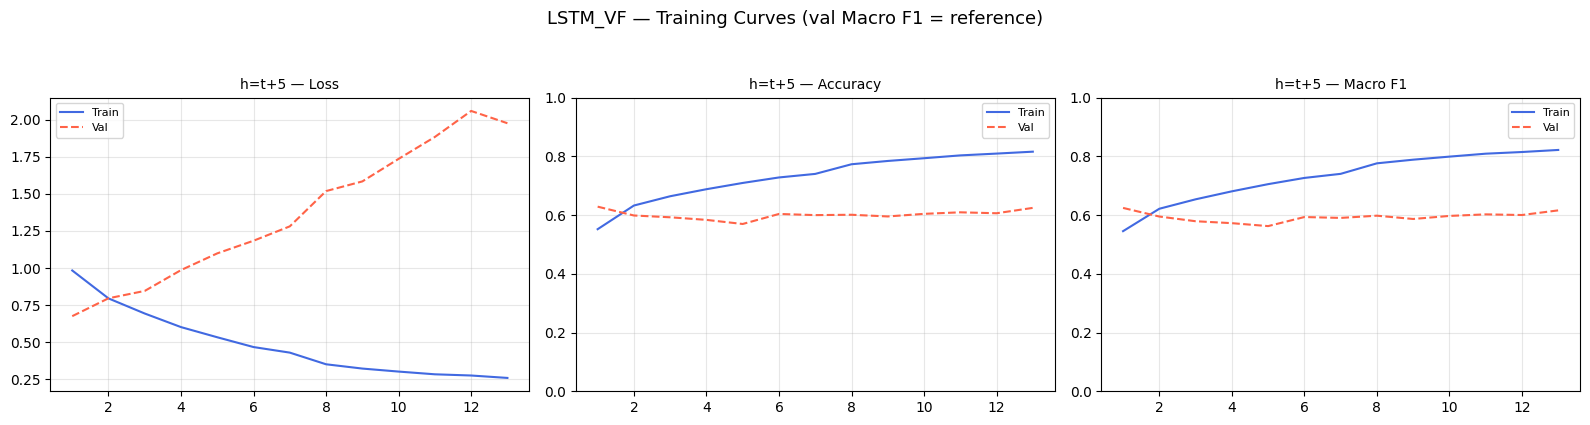

In [14]:
# ── Training curves ───────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))  # ← Fixed: Just 1 row now!
ep = range(1, len(history['train_loss']) + 1)

for col, (tr_k, va_k, title) in enumerate([
        ('train_loss', 'val_loss', 'Loss'),
        ('train_acc',  'val_acc',  'Accuracy'),
        ('train_f1',   'val_f1',   'Macro F1'),
    ]):
    ax = axes[col]  # ← Fixed: 1D array of axes
    ax.plot(ep, history[tr_k], label='Train', color='royalblue', lw=1.5)
    ax.plot(ep, history[va_k], label='Val',   color='tomato', ls='--', lw=1.5)
    ax.set_title(f'h=t+{CFG["horizon"]} — {title}', fontsize=10)
    ax.legend(fontsize=8)
    if 'loss' not in tr_k:
        ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

plt.suptitle('LSTM_VF — Training Curves (val Macro F1 = reference)', fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig('artifacts/lstm_vf_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ── Evaluation ────────────────────────────────────────────────────────────────

def evaluate(model):  # ← Fixed: Removed horizon param
    test_loader = make_loader(datasets['X_test'], datasets['y_test'])  # ← Fixed: Direct dataset access
    model.eval()
    all_preds, all_labels = [], []

    t0 = time.time()
    with torch.no_grad():
        for xb, yb in test_loader:
            logits = model(xb.to(DEVICE))
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(yb.numpy())

    lat = (time.time() - t0) / len(all_preds) * 1000
    p, l = np.array(all_preds), np.array(all_labels)

    return dict(
        preds       = p,
        labels      = l,
        acc         = accuracy_score(l, p),
        macro_f1    = f1_score(l, p, average='macro',    zero_division=0),
        weighted_f1 = f1_score(l, p, average='weighted', zero_division=0),
        report      = classification_report(l, p, target_names=label_encoder.classes_, zero_division=0),
        latency_ms  = lat,
    )

# Run evaluation once!
r = evaluate(model)
h = CFG['horizon']

print(f'\n{"="*60}')
print(f'  LSTM_VF | h=t+{h} (~{h*2}s ahead)')
print(f'  Accuracy   : {r["acc"]:.4f}')
print(f'  Macro F1   : {r["macro_f1"]:.4f}')
print(f'  Weighted F1: {r["weighted_f1"]:.4f}')
print(f'  Latency    : {r["latency_ms"]:.4f} ms/sample')
print(f'{"="*60}')
print(r['report'])


  LSTM_VF | h=t+5 (~10s ahead)
  Accuracy   : 0.6077
  Macro F1   : 0.6142
  Weighted F1: 0.6127
  Latency    : 0.0887 ms/sample
                    precision    recall  f1-score   support

         CALL_DROP       0.42      0.86      0.56      2779
CAPACITY_EXHAUSTED       0.45      0.90      0.60      1544
      HIGH_LATENCY       0.94      0.55      0.69      3684
    LOW_THROUGHPUT       0.77      0.66      0.71      4279
            NORMAL       0.74      0.45      0.56      7036
POOR_VOICE_QUALITY       0.53      0.58      0.55      3454

          accuracy                           0.61     22776
         macro avg       0.64      0.67      0.61     22776
      weighted avg       0.69      0.61      0.61     22776



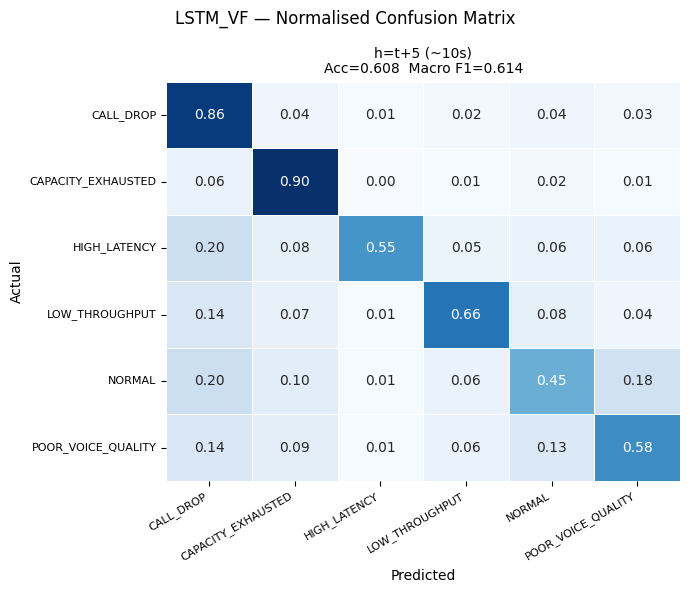

In [16]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 6))  # ← Fixed: Single plot, no subplots loop
cm = confusion_matrix(r['labels'], r['preds'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(np.round(cm_norm, 2), ax=ax, annot=True, fmt='.2f',
            cmap='Blues', linewidths=0.4, cbar=False,
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

ax.set_title(f'h=t+{h} (~{h*2}s)\nAcc={r["acc"]:.3f}  Macro F1={r["macro_f1"]:.3f}', fontsize=10)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_xticklabels(label_encoder.classes_, rotation=30, ha='right', fontsize=8)
ax.set_yticklabels(label_encoder.classes_, rotation=0, fontsize=8)

plt.suptitle('LSTM_VF — Normalised Confusion Matrix', fontsize=12)
plt.tight_layout()
plt.savefig('artifacts/lstm_vf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

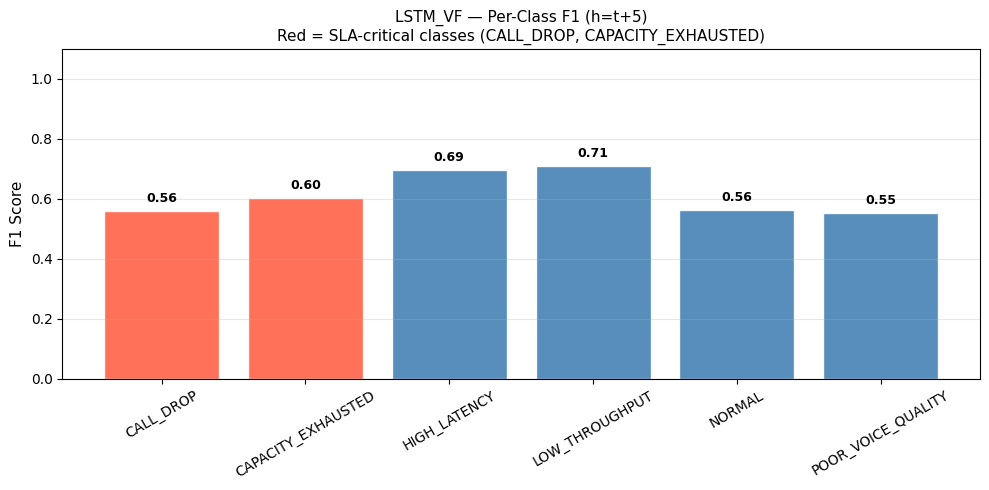

In [17]:
# ── Per-class F1 Bar Chart ──────────────────────────────────────────────────

pc_f1 = f1_score(r['labels'], r['preds'], average=None,
                 zero_division=0, labels=np.arange(NUM_CLASSES))

fig, ax = plt.subplots(figsize=(10, 5))

# Color minority classes RED, normal classes BLUE
colors = ['tomato' if cls in CFG['minority_boost_classes'] else 'steelblue'
          for cls in label_encoder.classes_]

bars = ax.bar(label_encoder.classes_, pc_f1, color=colors, edgecolor='white', alpha=0.9)

ax.set_ylabel('F1 Score', fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title(f'LSTM_VF — Per-Class F1 (h=t+{h})\nRed = SLA-critical classes (CALL_DROP, CAPACITY_EXHAUSTED)', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)

# Add numeric labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('artifacts/lstm_vf_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()